## 1. Imports and Setup

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 2. PINN Model Definition

In [9]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


## 3. Physics Residual (Core of PINN)

In [10]:
def pde_residual(model, x, E):
    x.requires_grad_(True)
    u = model(x)

    du_dx = torch.autograd.grad(
        u, x, torch.ones_like(u), create_graph=True
    )[0]

    d2u_dx2 = torch.autograd.grad(
        du_dx, x, torch.ones_like(du_dx), create_graph=True
    )[0]

    f = -torch.ones_like(x)  # body force
    return E * d2u_dx2 + f


## 4. Training Data (Collocation + Boundary Points)

In [11]:
# Collocation points (PDE)
x_pde = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)

# Boundary points
x_bc = torch.tensor([[0.0], [1.0]], device=device)


## 5. Model, Parameters, Optimizer

In [12]:
model = PINN().to(device)

# Treat Young's modulus as known (can be learned later)
E = torch.tensor(1.0, device=device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## 6. Training Loop

In [13]:
epochs = 5000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE loss
    res = pde_residual(model, x_pde, E)
    loss_pde = torch.mean(res**2)

    # Boundary condition loss
    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc**2)

    # Total loss
    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6e}")


Epoch     0 | Loss: 1.160548e+00
Epoch   500 | Loss: 2.679752e-05
Epoch  1000 | Loss: 1.350221e-05
Epoch  1500 | Loss: 4.218995e-06
Epoch  2000 | Loss: 4.153935e-07
Epoch  2500 | Loss: 3.008417e-07
Epoch  3000 | Loss: 2.362330e-07
Epoch  3500 | Loss: 1.981844e-07
Epoch  4000 | Loss: 1.769603e-07
Epoch  4500 | Loss: 1.604858e-07


## 7. Testing Against Analytical Solution

In [14]:
# Test grid
x_test = torch.linspace(0, 1, 200).reshape(-1, 1).to(device)

with torch.no_grad():
    u_pred = model(x_test)

# Analytical solution
u_exact = (x_test - x_test**2) / (2 * E)

# Relative L2 error
l2_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
print("\nRelative L2 Error:", l2_error.item())



Relative L2 Error: 1.9992214441299438


## 8. Visualization (Required for Validation)

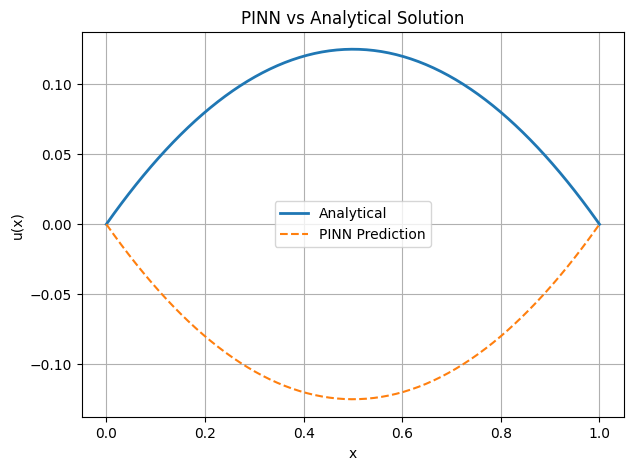

In [15]:
x_np = x_test.cpu().numpy()
u_pred_np = u_pred.cpu().numpy()
u_exact_np = u_exact.cpu().numpy()

plt.figure(figsize=(7,5))
plt.plot(x_np, u_exact_np, label="Analytical", linewidth=2)
plt.plot(x_np, u_pred_np, "--", label="PINN Prediction")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.title("PINN vs Analytical Solution")
plt.grid()
plt.show()


## 9. Error Distribution Plot

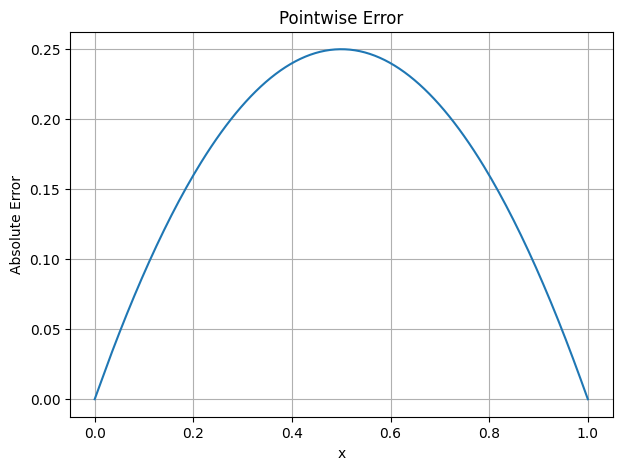

In [16]:
error = np.abs(u_pred_np - u_exact_np)

plt.figure(figsize=(7,5))
plt.plot(x_np, error)
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Pointwise Error")
plt.grid()
plt.show()


## 10. Training Loss Curve

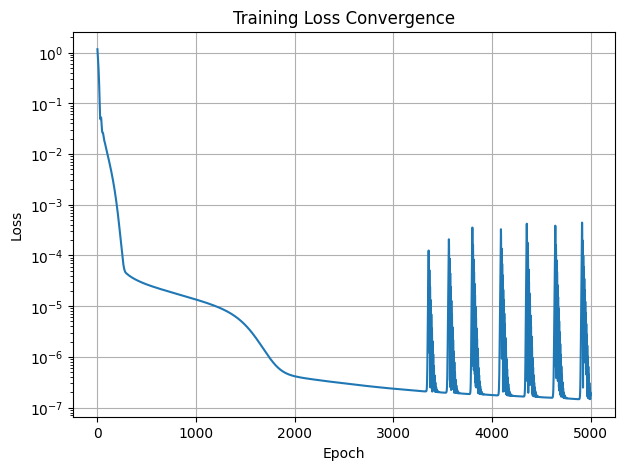

In [17]:
plt.figure(figsize=(7,5))
plt.semilogy(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Convergence")
plt.grid()
plt.show()


## 11. Save the Trained Model

In [ ]:
torch.save(model.state_dict(), "pinn_1d_elasticity.pt")
